In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [4]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [5]:
# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [6]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [7]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
# 归一化后的两个数据集
# 波浪-运动响应
# # Force
# # 输入50步长输出1步长
# force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
# force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# # 输入50步长输出3步长
# force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
# force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
# print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入50步长输出2步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x1,force150_y1 = split_sequence(force150_scaled2, 50)
print(force150_x1.shape)
# 输入100步长输出2步长
force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled2, 100)
print(force1100_x1.shape)


# 输入50步长输出4步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x2,force150_y2 = split_sequence(force150_scaled4, 50)
print(force150_x2.shape)
# 输入100步长输出4步长
force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
force1100_x2,force1100_y2 = split_sequence(force1100_scaled4, 100)
print(force1100_x2.shape)



# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x3,force150_y3 = split_sequence(force150_scaled6, 50)
print(force150_x3.shape)
# 输入100步长输出6步长
force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
force1100_x3,force1100_y3 = split_sequence(force1100_scaled6, 100)
print(force1100_x3.shape)



# 输入50步长输出8步长
force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x4,force150_y4 = split_sequence(force150_scaled8, 50)
print(force150_x4.shape)
# 输入100步长输出8步长
force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
force1100_x4,force1100_y4 = split_sequence(force1100_scaled8, 100)
print(force1100_x4.shape)




(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)


In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# # 输入50步长输出1步长
# heave50_scaled1 = deal_data2(np.hstack((H,Heave))[350:,:], 2, 50)
# heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 50)
# print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# # 输入50步长输出3步长
# heave50_scaled3 = deal_data2(np.hstack((H,Heave))[348:,:], 2, 52)
# heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 50)
# print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入50步长输出2步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[349:,:], 2, 51)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled2, 50)
print(heave50_x1.shape)
# 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入50步长输出4步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[347:,:], 2, 53)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled4, 50)
print(heave50_x2.shape)
# 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# 输入50步长输出6步长
heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled6, 50)
print(heave50_x3.shape)
# 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# 输入50步长输出8步长
heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled8, 50)
print(heave50_x4.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# # Surge
# # 输入50步长输出1步长
# surge50_scaled1 = deal_data2(np.hstack((H,Surge))[350:,:], 2, 50)
# surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 50)
# print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# # 输入50步长输出3步长
# surge50_scaled3 = deal_data2(np.hstack((H,Surge))[348:,:], 2, 52)
# surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 50)
# print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入50步长输出2步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[349:,:], 2, 51)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled2, 50)
print(surge50_x1.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入50步长输出4步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[347:,:], 2, 53)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled4, 50)
print(surge50_x2.shape)
# 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# 输入50步长输出6步长
surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled6, 50)
print(surge50_x3.shape)
# 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# 输入50步长输出8步长
surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled8, 50)
print(surge50_x4.shape)
# 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# # Pitch
# # 输入50步长输出1步长
# pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[350:,:], 2, 50)
# pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 50)
# print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# # 输入50步长输出3步长
# pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[348:,:], 2, 52)
# pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 50)
# print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入50步长输出2步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[349:,:], 2, 51)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled2, 50)
print(pitch50_x1.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入50步长输出4步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[347:,:], 2, 53)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled4, 50)
print(pitch50_x2.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# 输入50步长输出6步长
pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled6, 50)
print(pitch50_x3.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# 输入50步长输出8步长
pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled8, 50)
print(pitch50_x4.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)


#### 系泊缆力联合预测（时间窗50输出；步长2）

In [10]:
# 未来运动预测模型建立
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 6900, 7500, 12500)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 6600, 7500, 12500)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 6900, 7500, 12500)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 5000 samples
Epoch 1/30
 - 1s - loss: 0.0896 - val_loss: 0.0775
Epoch 2/30
 - 1s - loss: 0.0557 - val_loss: 0.0486
Epoch 3/30
 - 0s - loss: 0.0347 - val_loss: 0.0321
Epoch 4/30
 - 0s - loss: 0.0236 - val_loss: 0.0242
Epoch 5/30
 - 0s - loss: 0.0178 - val_loss: 0.0189
Epoch 6/30
 - 0s - loss: 0.0140 - val_loss: 0.0152
Epoch 7/30
 - 0s - loss: 0.0113 - val_loss: 0.0121
Epoch 8/30
 - 0s - loss: 0.0089 - val_loss: 0.0093
Epoch 9/30
 - 0s - loss: 0.0068 - val_loss: 0.0069
Epoch 10/30
 - 0s - loss: 0.0053 - val_loss: 0.0055
Epoch 11/30
 - 0s - loss: 0.0046 - val_loss: 0.0052
Epoch 12/30
 - 0s - loss: 0.0045 - val_loss: 0.0051
Epoch 13/30
 - 0s - loss: 0.0044 - val_loss: 0.0050
Epoch 14/30
 - 0s - loss: 0.0043 - val_loss: 0.0050
Epoch 15/30
 - 0s - loss: 0.0042 - val_loss: 0.0049
Epoch 16/30
 - 0s - loss: 0.0041 - val_loss: 0.0048
Epoch 17/30
 - 0s - loss: 0.0041 - val_loss: 0.0048
Epoch 18/30
 - 0s - loss: 0.0040 - val_loss: 0.0047
Epoch 19/30
 - 0s - loss: 

In [11]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

(600, 1)
(600, 1)
(600, 1)


In [12]:
# 输入50步长输出1步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [13]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 6900, 7500, 12500)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [14]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.0265 - val_loss: 0.0232
Epoch 2/1000
 - 0s - loss: 0.0221 - val_loss: 0.0122
Epoch 3/1000
 - 0s - loss: 0.0127 - val_loss: 0.0125
Epoch 4/1000
 - 0s - loss: 0.0118 - val_loss: 0.0132
Epoch 5/1000
 - 0s - loss: 0.0124 - val_loss: 0.0132
Epoch 6/1000
 - 0s - loss: 0.0127 - val_loss: 0.0117
Epoch 7/1000
 - 0s - loss: 0.0114 - val_loss: 0.0103
Epoch 8/1000
 - 0s - loss: 0.0101 - val_loss: 0.0104
Epoch 9/1000
 - 0s - loss: 0.0104 - val_loss: 0.0106
Epoch 10/1000
 - 0s - loss: 0.0103 - val_loss: 0.0107
Epoch 11/1000
 - 0s - loss: 0.0103 - val_loss: 0.0111
Epoch 12/1000
 - 0s - loss: 0.0103 - val_loss: 0.0105
Epoch 13/1000
 - 0s - loss: 0.0099 - val_loss: 0.0102
Epoch 14/1000
 - 0s - loss: 0.0099 - val_loss: 0.0100
Epoch 15/1000
 - 0s - loss: 0.0096 - val_loss: 0.0101
Epoch 16/1000
 - 0s - loss: 0.0095 - val_loss: 0.0105
Epoch 17/1000
 - 0s - loss: 0.0097 - val_loss: 0.0105
Epoch 18/1000
 - 0s - loss: 0.0097 - val_los

Epoch 152/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 153/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 154/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 155/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 156/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 157/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 158/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 159/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 160/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 161/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 162/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 163/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 164/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 165/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 166/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 167/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 168/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 169/1000
 - 0s - loss: 0.0090 - val_loss: 0.0110
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 302/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 303/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 304/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 305/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 306/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 307/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 308/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 309/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 310/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 311/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 312/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 313/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 314/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 315/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 316/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 317/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 318/1000
 - 0s - loss: 0.0080 - val_loss: 0.0109
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 451/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 452/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 453/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 454/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 455/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 456/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 457/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 458/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 459/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 460/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 461/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 462/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 463/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 464/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 465/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 466/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 467/1000
 - 0s - loss: 0.0080 - val_loss: 0.0107
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 600/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 601/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 602/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 603/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 604/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 605/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 606/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 607/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 608/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 609/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 610/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 611/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 612/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 613/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 614/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 615/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 616/1000
 - 0s - loss: 0.0078 - val_loss: 0.0102
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 749/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 750/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 751/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 752/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 753/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 754/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 755/1000
 - 0s - loss: 0.0077 - val_loss: 0.0106
Epoch 756/1000
 - 0s - loss: 0.0077 - val_loss: 0.0105
Epoch 757/1000
 - 0s - loss: 0.0077 - val_loss: 0.0107
Epoch 758/1000
 - 0s - loss: 0.0077 - val_loss: 0.0105
Epoch 759/1000
 - 0s - loss: 0.0076 - val_loss: 0.0107
Epoch 760/1000
 - 0s - loss: 0.0077 - val_loss: 0.0105
Epoch 761/1000
 - 0s - loss: 0.0077 - val_loss: 0.0108
Epoch 762/1000
 - 0s - loss: 0.0078 - val_loss: 0.0104
Epoch 763/1000
 - 0s - loss: 0.0077 - val_loss: 0.0110
Epoch 764/1000
 - 0s - loss: 0.0079 - val_loss: 0.0104
Epoch 765/1000
 - 0s - loss: 0.0078 - val_loss: 0.0115
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0074 - val_loss: 0.0111
Epoch 898/1000
 - 0s - loss: 0.0075 - val_loss: 0.0107
Epoch 899/1000
 - 0s - loss: 0.0075 - val_loss: 0.0113
Epoch 900/1000
 - 0s - loss: 0.0076 - val_loss: 0.0107
Epoch 901/1000
 - 0s - loss: 0.0075 - val_loss: 0.0116
Epoch 902/1000
 - 0s - loss: 0.0078 - val_loss: 0.0107
Epoch 903/1000
 - 0s - loss: 0.0078 - val_loss: 0.0123
Epoch 904/1000
 - 0s - loss: 0.0083 - val_loss: 0.0109
Epoch 905/1000
 - 0s - loss: 0.0083 - val_loss: 0.0139
Epoch 906/1000
 - 0s - loss: 0.0093 - val_loss: 0.0119
Epoch 907/1000
 - 0s - loss: 0.0096 - val_loss: 0.0174
Epoch 908/1000
 - 0s - loss: 0.0110 - val_loss: 0.0138
Epoch 909/1000
 - 0s - loss: 0.0112 - val_loss: 0.0179
Epoch 910/1000
 - 0s - loss: 0.0116 - val_loss: 0.0117
Epoch 911/1000
 - 0s - loss: 0.0103 - val_loss: 0.0116
Epoch 912/1000
 - 0s - loss: 0.0090 - val_loss: 0.0156
Epoch 913/1000
 - 0s - loss: 0.0099 - val_loss: 0.0121
Epoch 914/1000
 - 0s - loss: 0.0094 - val_loss: 0.0124
Epoch 915/

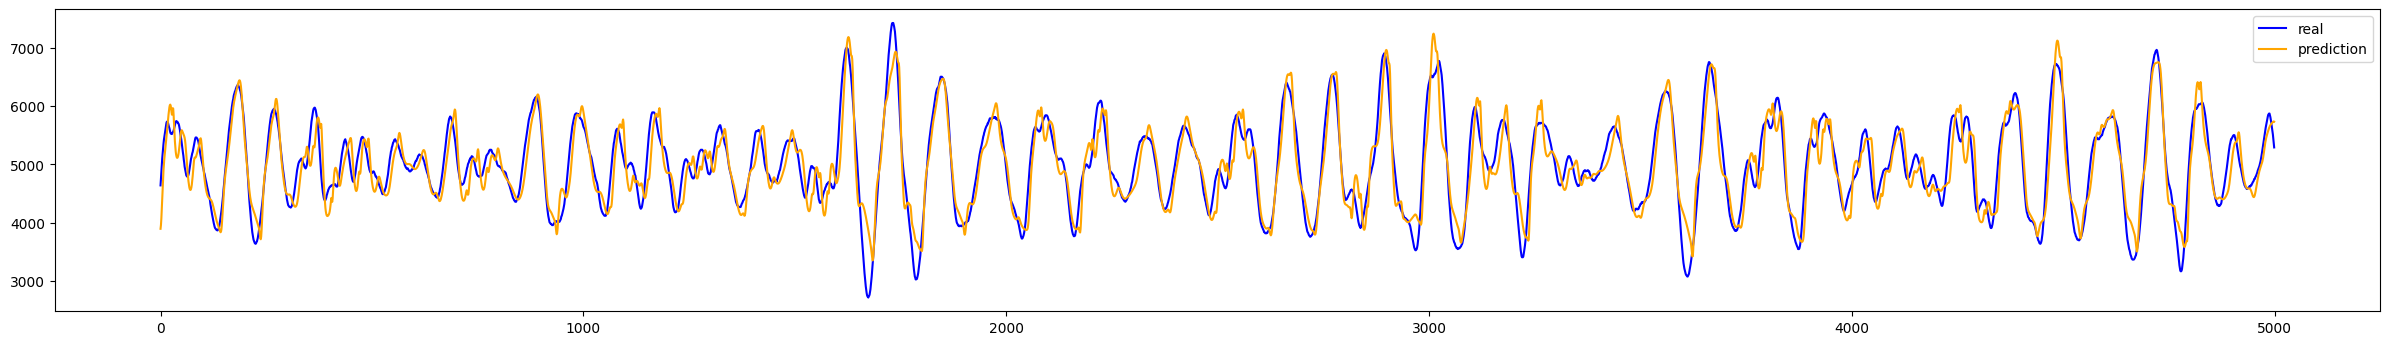

Acc: 0.9440694621745009


In [15]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force150_步长1.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [16]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[349:,:], 4, 51)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [17]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 6900, 7500, 12500)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [18]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.1102 - val_loss: 0.0492
Epoch 2/1000
 - 0s - loss: 0.0536 - val_loss: 0.0466
Epoch 3/1000
 - 0s - loss: 0.0447 - val_loss: 0.0378
Epoch 4/1000
 - 0s - loss: 0.0474 - val_loss: 0.0445
Epoch 5/1000
 - 0s - loss: 0.0528 - val_loss: 0.0404
Epoch 6/1000
 - 0s - loss: 0.0470 - val_loss: 0.0368
Epoch 7/1000
 - 0s - loss: 0.0425 - val_loss: 0.0372
Epoch 8/1000
 - 0s - loss: 0.0411 - val_loss: 0.0356
Epoch 9/1000
 - 0s - loss: 0.0398 - val_loss: 0.0346
Epoch 10/1000
 - 0s - loss: 0.0404 - val_loss: 0.0358
Epoch 11/1000
 - 0s - loss: 0.0417 - val_loss: 0.0355
Epoch 12/1000
 - 0s - loss: 0.0407 - val_loss: 0.0339
Epoch 13/1000
 - 0s - loss: 0.0386 - val_loss: 0.0335
Epoch 14/1000
 - 0s - loss: 0.0373 - val_loss: 0.0332
Epoch 15/1000
 - 0s - loss: 0.0366 - val_loss: 0.0335
Epoch 16/1000
 - 0s - loss: 0.0369 - val_loss: 0.0335
Epoch 17/1000
 - 0s - loss: 0.0367 - val_loss: 0.0328
Epoch 18/1000
 - 0s - loss: 0.0354 - val_los

Epoch 152/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 153/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 154/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 155/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 156/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 157/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 158/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 159/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 160/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 161/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 162/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 163/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 164/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 165/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 166/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 167/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 168/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 169/1000
 - 0s - loss: 0.0307 - val_loss: 0.0396
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 302/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 303/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 304/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 305/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 306/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 307/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 308/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 309/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 310/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 311/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 312/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 313/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 314/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 315/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 316/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 317/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 318/1000
 - 0s - loss: 0.0306 - val_loss: 0.0396
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0270 - val_loss: 0.0375
Epoch 451/1000
 - 0s - loss: 0.0269 - val_loss: 0.0375
Epoch 452/1000
 - 0s - loss: 0.0270 - val_loss: 0.0375
Epoch 453/1000
 - 0s - loss: 0.0269 - val_loss: 0.0376
Epoch 454/1000
 - 0s - loss: 0.0270 - val_loss: 0.0375
Epoch 455/1000
 - 0s - loss: 0.0269 - val_loss: 0.0376
Epoch 456/1000
 - 0s - loss: 0.0270 - val_loss: 0.0374
Epoch 457/1000
 - 0s - loss: 0.0269 - val_loss: 0.0377
Epoch 458/1000
 - 0s - loss: 0.0272 - val_loss: 0.0373
Epoch 459/1000
 - 0s - loss: 0.0269 - val_loss: 0.0379
Epoch 460/1000
 - 0s - loss: 0.0275 - val_loss: 0.0372
Epoch 461/1000
 - 0s - loss: 0.0272 - val_loss: 0.0383
Epoch 462/1000
 - 0s - loss: 0.0284 - val_loss: 0.0373
Epoch 463/1000
 - 0s - loss: 0.0282 - val_loss: 0.0400
Epoch 464/1000
 - 0s - loss: 0.0303 - val_loss: 0.0388
Epoch 465/1000
 - 0s - loss: 0.0308 - val_loss: 0.0460
Epoch 466/1000
 - 0s - loss: 0.0330 - val_loss: 0.0443
Epoch 467/1000
 - 0s - loss: 0.0342 - val_loss: 0.0504
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 600/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 601/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 602/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 603/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 604/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 605/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 606/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 607/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 608/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 609/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 610/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 611/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 612/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 613/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 614/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 615/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 616/1000
 - 0s - loss: 0.0266 - val_loss: 0.0374
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0257 - val_loss: 0.0388
Epoch 749/1000
 - 0s - loss: 0.0257 - val_loss: 0.0388
Epoch 750/1000
 - 0s - loss: 0.0257 - val_loss: 0.0388
Epoch 751/1000
 - 0s - loss: 0.0257 - val_loss: 0.0389
Epoch 752/1000
 - 0s - loss: 0.0257 - val_loss: 0.0389
Epoch 753/1000
 - 0s - loss: 0.0257 - val_loss: 0.0389
Epoch 754/1000
 - 0s - loss: 0.0257 - val_loss: 0.0389
Epoch 755/1000
 - 0s - loss: 0.0257 - val_loss: 0.0389
Epoch 756/1000
 - 0s - loss: 0.0257 - val_loss: 0.0390
Epoch 757/1000
 - 0s - loss: 0.0257 - val_loss: 0.0390
Epoch 758/1000
 - 0s - loss: 0.0256 - val_loss: 0.0390
Epoch 759/1000
 - 0s - loss: 0.0256 - val_loss: 0.0390
Epoch 760/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 761/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 762/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 763/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 764/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 765/1000
 - 0s - loss: 0.0256 - val_loss: 0.0391
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 898/1000
 - 0s - loss: 0.0255 - val_loss: 0.0399
Epoch 899/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 900/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 901/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 902/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 903/1000
 - 0s - loss: 0.0254 - val_loss: 0.0399
Epoch 904/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 905/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 906/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 907/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 908/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 909/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 910/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 911/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 912/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 913/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 914/1000
 - 0s - loss: 0.0254 - val_loss: 0.0400
Epoch 915/

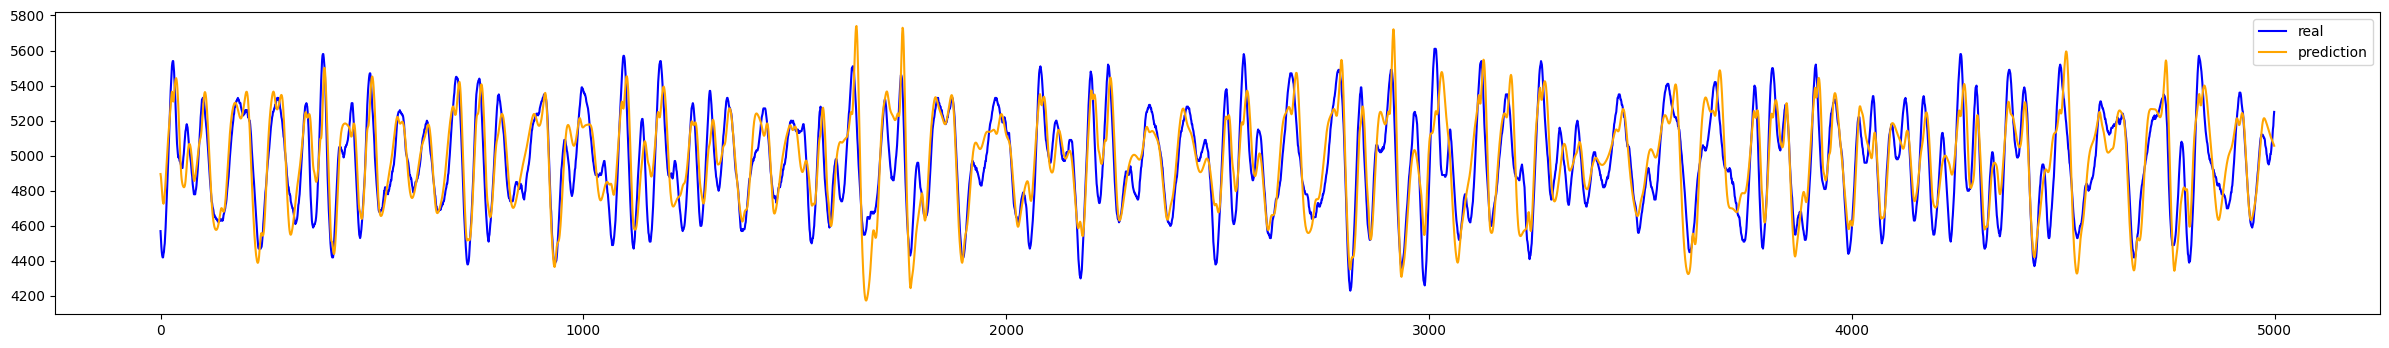

Acc: 0.967631164189931


In [19]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force250_步长1.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长4）

In [20]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 6900, 7500, 12500)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_LSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 6600, 7500, 12500)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_LSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 6900, 7500, 12500)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_LSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 5000 samples
Epoch 1/30
 - 1s - loss: 0.0400 - val_loss: 0.0355
Epoch 2/30
 - 1s - loss: 0.0266 - val_loss: 0.0278
Epoch 3/30
 - 1s - loss: 0.0214 - val_loss: 0.0237
Epoch 4/30
 - 1s - loss: 0.0181 - val_loss: 0.0202
Epoch 5/30
 - 1s - loss: 0.0154 - val_loss: 0.0172
Epoch 6/30
 - 1s - loss: 0.0130 - val_loss: 0.0141
Epoch 7/30
 - 0s - loss: 0.0105 - val_loss: 0.0107
Epoch 8/30
 - 1s - loss: 0.0080 - val_loss: 0.0076
Epoch 9/30
 - 0s - loss: 0.0063 - val_loss: 0.0064
Epoch 10/30
 - 1s - loss: 0.0058 - val_loss: 0.0062
Epoch 11/30
 - 1s - loss: 0.0055 - val_loss: 0.0061
Epoch 12/30
 - 1s - loss: 0.0052 - val_loss: 0.0061
Epoch 13/30
 - 1s - loss: 0.0051 - val_loss: 0.0060
Epoch 14/30
 - 0s - loss: 0.0050 - val_loss: 0.0060
Epoch 15/30
 - 0s - loss: 0.0049 - val_loss: 0.0059
Epoch 16/30
 - 0s - loss: 0.0048 - val_loss: 0.0058
Epoch 17/30
 - 0s - loss: 0.0048 - val_loss: 0.0057
Epoch 18/30
 - 1s - loss: 0.0047 - val_loss: 0.0056
Epoch 19/30
 - 1s - loss: 

In [21]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

(600, 1)
(600, 1)
(600, 1)


In [22]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [23]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 6900, 7500, 12500)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [24]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.0378 - val_loss: 0.0248
Epoch 2/1000
 - 0s - loss: 0.0270 - val_loss: 0.0248
Epoch 3/1000
 - 0s - loss: 0.0215 - val_loss: 0.0146
Epoch 4/1000
 - 0s - loss: 0.0142 - val_loss: 0.0161
Epoch 5/1000
 - 0s - loss: 0.0136 - val_loss: 0.0150
Epoch 6/1000
 - 0s - loss: 0.0127 - val_loss: 0.0161
Epoch 7/1000
 - 0s - loss: 0.0141 - val_loss: 0.0171
Epoch 8/1000
 - 0s - loss: 0.0151 - val_loss: 0.0155
Epoch 9/1000
 - 0s - loss: 0.0135 - val_loss: 0.0136
Epoch 10/1000
 - 0s - loss: 0.0118 - val_loss: 0.0134
Epoch 11/1000
 - 0s - loss: 0.0117 - val_loss: 0.0136
Epoch 12/1000
 - 0s - loss: 0.0115 - val_loss: 0.0142
Epoch 13/1000
 - 0s - loss: 0.0118 - val_loss: 0.0151
Epoch 14/1000
 - 0s - loss: 0.0125 - val_loss: 0.0150
Epoch 15/1000
 - 0s - loss: 0.0123 - val_loss: 0.0143
Epoch 16/1000
 - 0s - loss: 0.0118 - val_loss: 0.0140
Epoch 17/1000
 - 0s - loss: 0.0116 - val_loss: 0.0141
Epoch 18/1000
 - 0s - loss: 0.0114 - val_los

Epoch 152/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 153/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 154/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 155/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 156/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 157/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 158/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 159/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 160/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 161/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 162/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 163/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 164/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 165/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 166/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 167/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 168/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 169/1000
 - 0s - loss: 0.0117 - val_loss: 0.0147
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0116 - val_loss: 0.0148
Epoch 302/1000
 - 0s - loss: 0.0116 - val_loss: 0.0148
Epoch 303/1000
 - 0s - loss: 0.0116 - val_loss: 0.0149
Epoch 304/1000
 - 0s - loss: 0.0116 - val_loss: 0.0149
Epoch 305/1000
 - 0s - loss: 0.0116 - val_loss: 0.0149
Epoch 306/1000
 - 0s - loss: 0.0116 - val_loss: 0.0149
Epoch 307/1000
 - 0s - loss: 0.0116 - val_loss: 0.0149
Epoch 308/1000
 - 0s - loss: 0.0115 - val_loss: 0.0149
Epoch 309/1000
 - 0s - loss: 0.0115 - val_loss: 0.0149
Epoch 310/1000
 - 0s - loss: 0.0115 - val_loss: 0.0150
Epoch 311/1000
 - 0s - loss: 0.0115 - val_loss: 0.0150
Epoch 312/1000
 - 0s - loss: 0.0115 - val_loss: 0.0150
Epoch 313/1000
 - 0s - loss: 0.0115 - val_loss: 0.0150
Epoch 314/1000
 - 0s - loss: 0.0115 - val_loss: 0.0150
Epoch 315/1000
 - 0s - loss: 0.0115 - val_loss: 0.0151
Epoch 316/1000
 - 0s - loss: 0.0115 - val_loss: 0.0151
Epoch 317/1000
 - 0s - loss: 0.0115 - val_loss: 0.0151
Epoch 318/1000
 - 0s - loss: 0.0115 - val_loss: 0.0151
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 451/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 452/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 453/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 454/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 455/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 456/1000
 - 0s - loss: 0.0114 - val_loss: 0.0161
Epoch 457/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 458/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 459/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 460/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 461/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 462/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 463/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 464/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 465/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 466/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 467/1000
 - 0s - loss: 0.0114 - val_loss: 0.0162
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0113 - val_loss: 0.0164
Epoch 600/1000
 - 0s - loss: 0.0113 - val_loss: 0.0164
Epoch 601/1000
 - 0s - loss: 0.0113 - val_loss: 0.0164
Epoch 602/1000
 - 0s - loss: 0.0113 - val_loss: 0.0164
Epoch 603/1000
 - 0s - loss: 0.0113 - val_loss: 0.0164
Epoch 604/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 605/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 606/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 607/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 608/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 609/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 610/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 611/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 612/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 613/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 614/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 615/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 616/1000
 - 0s - loss: 0.0113 - val_loss: 0.0165
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 749/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 750/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 751/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 752/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 753/1000
 - 0s - loss: 0.0110 - val_loss: 0.0170
Epoch 754/1000
 - 0s - loss: 0.0109 - val_loss: 0.0170
Epoch 755/1000
 - 0s - loss: 0.0109 - val_loss: 0.0170
Epoch 756/1000
 - 0s - loss: 0.0109 - val_loss: 0.0170
Epoch 757/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 758/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 759/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 760/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 761/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 762/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 763/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 764/1000
 - 0s - loss: 0.0109 - val_loss: 0.0171
Epoch 765/1000
 - 0s - loss: 0.0109 - val_loss: 0.0172
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0098 - val_loss: 0.0200
Epoch 898/1000
 - 0s - loss: 0.0098 - val_loss: 0.0201
Epoch 899/1000
 - 0s - loss: 0.0098 - val_loss: 0.0201
Epoch 900/1000
 - 0s - loss: 0.0098 - val_loss: 0.0201
Epoch 901/1000
 - 0s - loss: 0.0098 - val_loss: 0.0201
Epoch 902/1000
 - 0s - loss: 0.0098 - val_loss: 0.0201
Epoch 903/1000
 - 0s - loss: 0.0098 - val_loss: 0.0202
Epoch 904/1000
 - 0s - loss: 0.0098 - val_loss: 0.0202
Epoch 905/1000
 - 0s - loss: 0.0098 - val_loss: 0.0202
Epoch 906/1000
 - 0s - loss: 0.0098 - val_loss: 0.0202
Epoch 907/1000
 - 0s - loss: 0.0098 - val_loss: 0.0202
Epoch 908/1000
 - 0s - loss: 0.0098 - val_loss: 0.0203
Epoch 909/1000
 - 0s - loss: 0.0098 - val_loss: 0.0203
Epoch 910/1000
 - 0s - loss: 0.0098 - val_loss: 0.0203
Epoch 911/1000
 - 0s - loss: 0.0098 - val_loss: 0.0203
Epoch 912/1000
 - 0s - loss: 0.0097 - val_loss: 0.0203
Epoch 913/1000
 - 0s - loss: 0.0097 - val_loss: 0.0204
Epoch 914/1000
 - 0s - loss: 0.0097 - val_loss: 0.0204
Epoch 915/

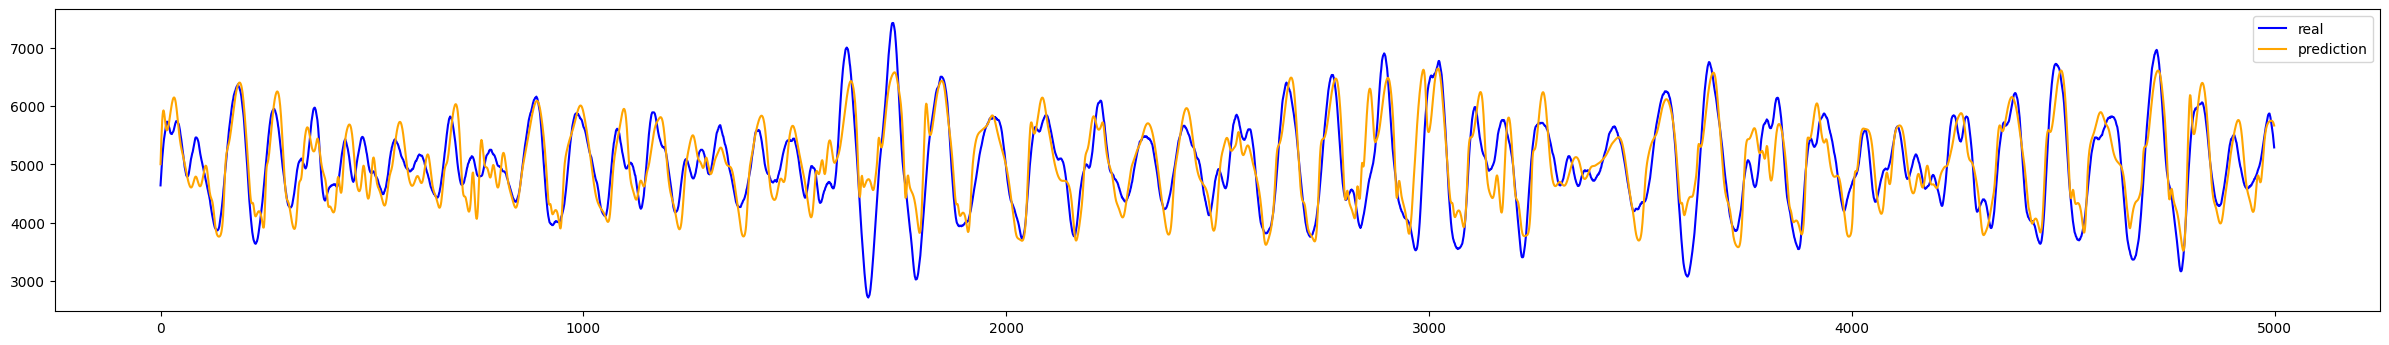

Acc: 0.9693174472651489


In [25]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force150_步长2.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [26]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[347:,:], 4, 53)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [27]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 6900, 7500, 12500)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [28]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.1585 - val_loss: 0.0544
Epoch 2/1000
 - 0s - loss: 0.0667 - val_loss: 0.0774
Epoch 3/1000
 - 0s - loss: 0.0693 - val_loss: 0.0490
Epoch 4/1000
 - 0s - loss: 0.0519 - val_loss: 0.0468
Epoch 5/1000
 - 0s - loss: 0.0561 - val_loss: 0.0540
Epoch 6/1000
 - 0s - loss: 0.0609 - val_loss: 0.0508
Epoch 7/1000
 - 0s - loss: 0.0553 - val_loss: 0.0437
Epoch 8/1000
 - 0s - loss: 0.0479 - val_loss: 0.0423
Epoch 9/1000
 - 0s - loss: 0.0453 - val_loss: 0.0424
Epoch 10/1000
 - 0s - loss: 0.0432 - val_loss: 0.0398
Epoch 11/1000
 - 0s - loss: 0.0412 - val_loss: 0.0389
Epoch 12/1000
 - 0s - loss: 0.0418 - val_loss: 0.0388
Epoch 13/1000
 - 0s - loss: 0.0421 - val_loss: 0.0374
Epoch 14/1000
 - 0s - loss: 0.0401 - val_loss: 0.0363
Epoch 15/1000
 - 0s - loss: 0.0374 - val_loss: 0.0369
Epoch 16/1000
 - 0s - loss: 0.0358 - val_loss: 0.0372
Epoch 17/1000
 - 0s - loss: 0.0349 - val_loss: 0.0369
Epoch 18/1000
 - 0s - loss: 0.0349 - val_los

 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 152/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 153/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 154/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 155/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 156/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 157/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 158/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 159/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 160/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 161/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 162/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 163/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 164/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 165/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 166/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 167/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 168/1000
 - 0s - loss: 0.0335 - val_loss: 0.0409
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 301/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 302/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 303/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 304/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 305/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 306/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 307/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 308/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 309/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 310/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 311/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 312/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 313/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 314/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 315/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 316/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 317/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 318/1000
 - 0s - lo

Epoch 450/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 451/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 452/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 453/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 454/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 455/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 456/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 457/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 458/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 459/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 460/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 461/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 462/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 463/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 464/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 465/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 466/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 467/1000
 - 0s - loss: 0.0334 - val_loss: 0.0409
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 600/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 601/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 602/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 603/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 604/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 605/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 606/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 607/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 608/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 609/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 610/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 611/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 612/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 613/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 614/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 615/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 616/1000
 - 0s - loss: 0.0333 - val_loss: 0.0409
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0309 - val_loss: 0.0458
Epoch 749/1000
 - 0s - loss: 0.0309 - val_loss: 0.0458
Epoch 750/1000
 - 0s - loss: 0.0309 - val_loss: 0.0458
Epoch 751/1000
 - 0s - loss: 0.0309 - val_loss: 0.0458
Epoch 752/1000
 - 0s - loss: 0.0309 - val_loss: 0.0459
Epoch 753/1000
 - 0s - loss: 0.0309 - val_loss: 0.0459
Epoch 754/1000
 - 0s - loss: 0.0309 - val_loss: 0.0459
Epoch 755/1000
 - 0s - loss: 0.0309 - val_loss: 0.0459
Epoch 756/1000
 - 0s - loss: 0.0309 - val_loss: 0.0460
Epoch 757/1000
 - 0s - loss: 0.0308 - val_loss: 0.0460
Epoch 758/1000
 - 0s - loss: 0.0308 - val_loss: 0.0460
Epoch 759/1000
 - 0s - loss: 0.0308 - val_loss: 0.0460
Epoch 760/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 761/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 762/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 763/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 764/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 765/1000
 - 0s - loss: 0.0308 - val_loss: 0.0461
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0272 - val_loss: 0.0464
Epoch 898/1000
 - 0s - loss: 0.0272 - val_loss: 0.0464
Epoch 899/1000
 - 0s - loss: 0.0272 - val_loss: 0.0464
Epoch 900/1000
 - 0s - loss: 0.0272 - val_loss: 0.0464
Epoch 901/1000
 - 0s - loss: 0.0272 - val_loss: 0.0463
Epoch 902/1000
 - 0s - loss: 0.0272 - val_loss: 0.0463
Epoch 903/1000
 - 0s - loss: 0.0271 - val_loss: 0.0463
Epoch 904/1000
 - 0s - loss: 0.0271 - val_loss: 0.0463
Epoch 905/1000
 - 0s - loss: 0.0271 - val_loss: 0.0462
Epoch 906/1000
 - 0s - loss: 0.0271 - val_loss: 0.0462
Epoch 907/1000
 - 0s - loss: 0.0271 - val_loss: 0.0462
Epoch 908/1000
 - 0s - loss: 0.0271 - val_loss: 0.0462
Epoch 909/1000
 - 0s - loss: 0.0271 - val_loss: 0.0461
Epoch 910/1000
 - 0s - loss: 0.0271 - val_loss: 0.0461
Epoch 911/1000
 - 0s - loss: 0.0270 - val_loss: 0.0461
Epoch 912/1000
 - 0s - loss: 0.0270 - val_loss: 0.0460
Epoch 913/1000
 - 0s - loss: 0.0270 - val_loss: 0.0460
Epoch 914/1000
 - 0s - loss: 0.0270 - val_loss: 0.0460
Epoch 915/

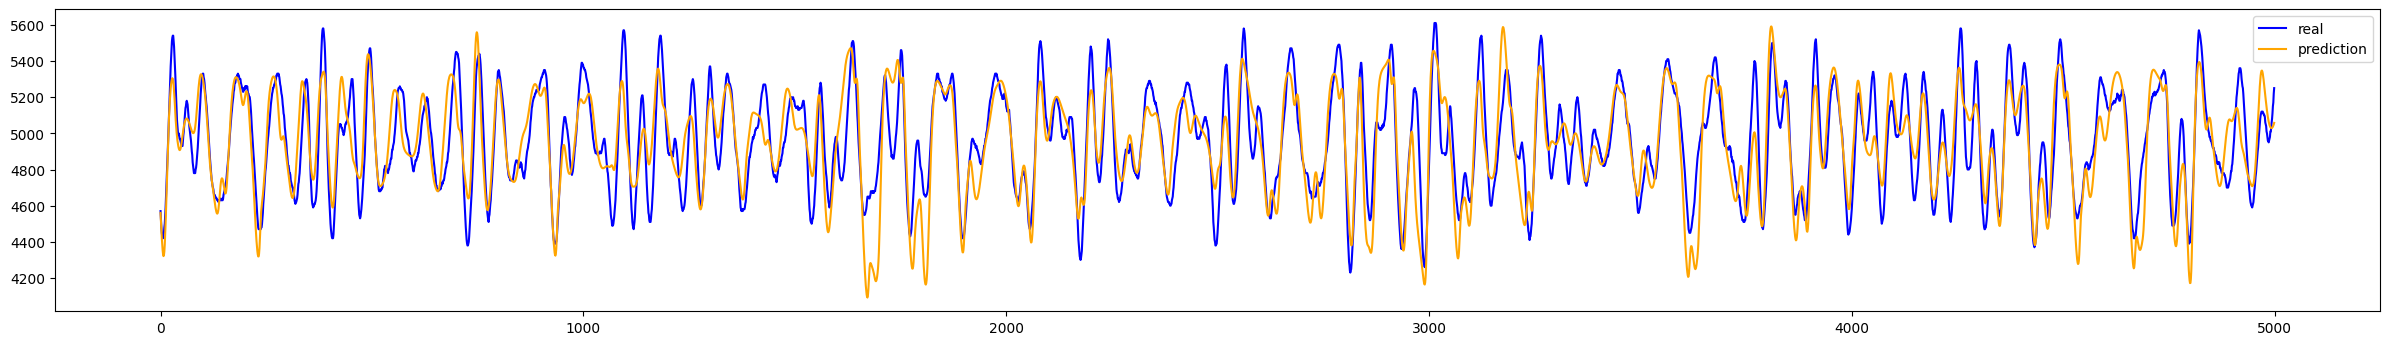

Acc: 0.9973259127691899


In [29]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force250_步长2.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长6）

In [30]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 6900, 7500, 12500)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_LSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 6600, 7500, 12500)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_LSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 6900, 7500, 12500)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_LSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 5000 samples
Epoch 1/30
 - 1s - loss: 0.0538 - val_loss: 0.0496
Epoch 2/30
 - 1s - loss: 0.0372 - val_loss: 0.0358
Epoch 3/30
 - 1s - loss: 0.0276 - val_loss: 0.0289
Epoch 4/30
 - 1s - loss: 0.0221 - val_loss: 0.0225
Epoch 5/30
 - 1s - loss: 0.0167 - val_loss: 0.0158
Epoch 6/30
 - 1s - loss: 0.0114 - val_loss: 0.0107
Epoch 7/30
 - 1s - loss: 0.0092 - val_loss: 0.0109
Epoch 8/30
 - 1s - loss: 0.0089 - val_loss: 0.0099
Epoch 9/30
 - 1s - loss: 0.0080 - val_loss: 0.0102
Epoch 10/30
 - 1s - loss: 0.0081 - val_loss: 0.0096
Epoch 11/30
 - 1s - loss: 0.0077 - val_loss: 0.0099
Epoch 12/30
 - 1s - loss: 0.0078 - val_loss: 0.0094
Epoch 13/30
 - 1s - loss: 0.0075 - val_loss: 0.0095
Epoch 14/30
 - 1s - loss: 0.0075 - val_loss: 0.0092
Epoch 15/30
 - 1s - loss: 0.0073 - val_loss: 0.0092
Epoch 16/30
 - 1s - loss: 0.0073 - val_loss: 0.0090
Epoch 17/30
 - 1s - loss: 0.0072 - val_loss: 0.0090
Epoch 18/30
 - 1s - loss: 0.0071 - val_loss: 0.0088
Epoch 19/30
 - 1s - loss: 

In [31]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

(600, 1)
(600, 1)
(600, 1)


In [32]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [33]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 6900, 7500, 12500)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [34]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.0389 - val_loss: 0.0308
Epoch 2/1000
 - 0s - loss: 0.0294 - val_loss: 0.0238
Epoch 3/1000
 - 0s - loss: 0.0206 - val_loss: 0.0179
Epoch 4/1000
 - 0s - loss: 0.0161 - val_loss: 0.0185
Epoch 5/1000
 - 0s - loss: 0.0141 - val_loss: 0.0170
Epoch 6/1000
 - 0s - loss: 0.0135 - val_loss: 0.0204
Epoch 7/1000
 - 0s - loss: 0.0168 - val_loss: 0.0211
Epoch 8/1000
 - 0s - loss: 0.0167 - val_loss: 0.0185
Epoch 9/1000
 - 0s - loss: 0.0143 - val_loss: 0.0175
Epoch 10/1000
 - 0s - loss: 0.0132 - val_loss: 0.0176
Epoch 11/1000
 - 0s - loss: 0.0132 - val_loss: 0.0178
Epoch 12/1000
 - 0s - loss: 0.0136 - val_loss: 0.0185
Epoch 13/1000
 - 0s - loss: 0.0142 - val_loss: 0.0189
Epoch 14/1000
 - 0s - loss: 0.0142 - val_loss: 0.0188
Epoch 15/1000
 - 0s - loss: 0.0138 - val_loss: 0.0188
Epoch 16/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 17/1000
 - 0s - loss: 0.0135 - val_loss: 0.0187
Epoch 18/1000
 - 0s - loss: 0.0137 - val_los

 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 152/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 153/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 154/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 155/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 156/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 157/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 158/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 159/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 160/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 161/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 162/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 163/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 164/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 165/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 166/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 167/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 168/1000
 - 0s - loss: 0.0137 - val_loss: 0.0187
Epoch 169/1000
 - 0s - lo

Epoch 300/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 301/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 302/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 303/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 304/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 305/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 306/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 307/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 308/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 309/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 310/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 311/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 312/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 313/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 314/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 315/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 316/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 317/1000
 - 0s - loss: 0.0136 - val_loss: 0.0187
Epoch 318/

Epoch 449/1000
 - 0s - loss: 0.0135 - val_loss: 0.0190
Epoch 450/1000
 - 0s - loss: 0.0135 - val_loss: 0.0190
Epoch 451/1000
 - 0s - loss: 0.0135 - val_loss: 0.0190
Epoch 452/1000
 - 0s - loss: 0.0134 - val_loss: 0.0191
Epoch 453/1000
 - 0s - loss: 0.0134 - val_loss: 0.0191
Epoch 454/1000
 - 0s - loss: 0.0134 - val_loss: 0.0191
Epoch 455/1000
 - 0s - loss: 0.0134 - val_loss: 0.0191
Epoch 456/1000
 - 0s - loss: 0.0134 - val_loss: 0.0192
Epoch 457/1000
 - 0s - loss: 0.0134 - val_loss: 0.0192
Epoch 458/1000
 - 0s - loss: 0.0134 - val_loss: 0.0192
Epoch 459/1000
 - 0s - loss: 0.0134 - val_loss: 0.0192
Epoch 460/1000
 - 0s - loss: 0.0134 - val_loss: 0.0192
Epoch 461/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 462/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 463/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 464/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 465/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 466/1000
 - 0s - loss: 0.0134 - val_loss: 0.0193
Epoch 467/

Epoch 598/1000
 - 0s - loss: 0.0133 - val_loss: 0.0197
Epoch 599/1000
 - 0s - loss: 0.0133 - val_loss: 0.0197
Epoch 600/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 601/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 602/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 603/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 604/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 605/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 606/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 607/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 608/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 609/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 610/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 611/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 612/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 613/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 614/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 615/1000
 - 0s - loss: 0.0133 - val_loss: 0.0198
Epoch 616/

Epoch 747/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 748/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 749/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 750/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 751/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 752/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 753/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 754/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 755/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 756/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 757/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 758/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 759/1000
 - 0s - loss: 0.0133 - val_loss: 0.0199
Epoch 760/1000
 - 0s - loss: 0.0133 - val_loss: 0.0200
Epoch 761/1000
 - 0s - loss: 0.0133 - val_loss: 0.0200
Epoch 762/1000
 - 0s - loss: 0.0133 - val_loss: 0.0200
Epoch 763/1000
 - 0s - loss: 0.0133 - val_loss: 0.0200
Epoch 764/1000
 - 0s - loss: 0.0133 - val_loss: 0.0200
Epoch 765/

Epoch 896/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 897/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 898/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 899/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 900/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 901/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 902/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 903/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 904/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 905/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 906/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 907/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 908/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 909/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 910/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 911/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 912/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 913/1000
 - 0s - loss: 0.0133 - val_loss: 0.0201
Epoch 914/

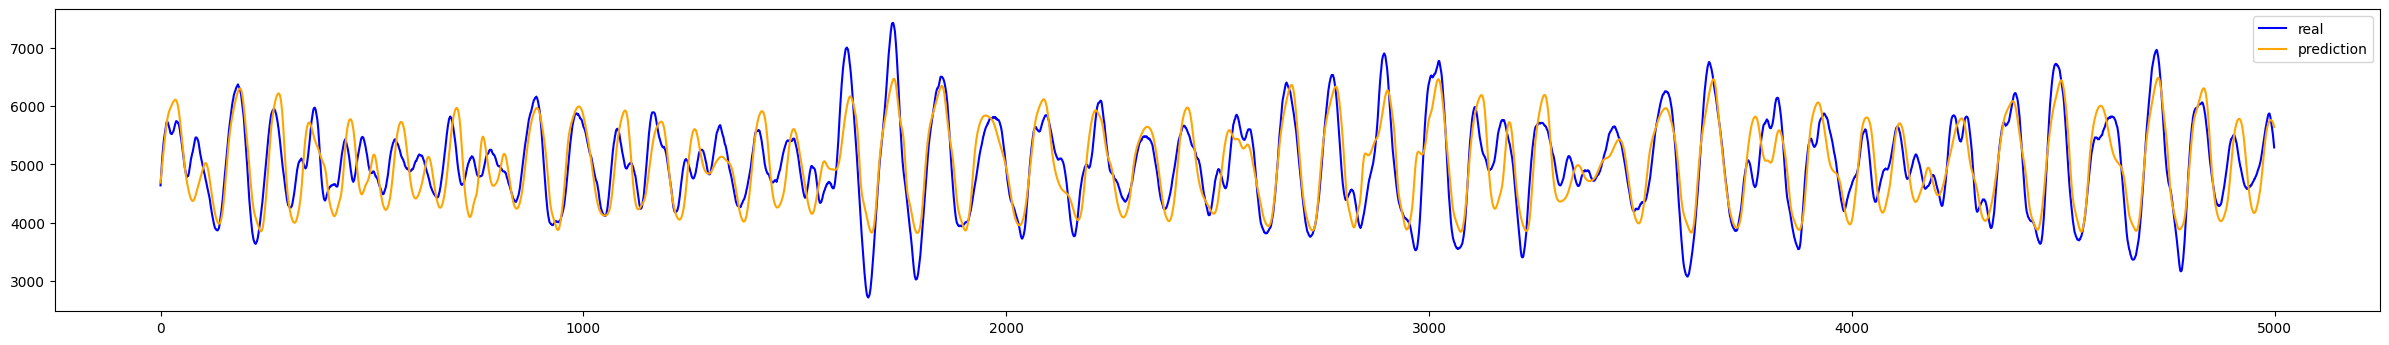

Acc: 0.9863548106066772


In [35]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force150_步长3.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [36]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[345:,:], 4, 55)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [37]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 6900, 7500, 12500)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [38]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.1034 - val_loss: 0.0557
Epoch 2/1000
 - 0s - loss: 0.0588 - val_loss: 0.0563
Epoch 3/1000
 - 0s - loss: 0.0521 - val_loss: 0.0451
Epoch 4/1000
 - 0s - loss: 0.0497 - val_loss: 0.0457
Epoch 5/1000
 - 0s - loss: 0.0500 - val_loss: 0.0389
Epoch 6/1000
 - 0s - loss: 0.0420 - val_loss: 0.0364
Epoch 7/1000
 - 0s - loss: 0.0373 - val_loss: 0.0363
Epoch 8/1000
 - 0s - loss: 0.0337 - val_loss: 0.0327
Epoch 9/1000
 - 0s - loss: 0.0310 - val_loss: 0.0338
Epoch 10/1000
 - 0s - loss: 0.0317 - val_loss: 0.0347
Epoch 11/1000
 - 0s - loss: 0.0303 - val_loss: 0.0360
Epoch 12/1000
 - 0s - loss: 0.0282 - val_loss: 0.0365
Epoch 13/1000
 - 0s - loss: 0.0267 - val_loss: 0.0373
Epoch 14/1000
 - 0s - loss: 0.0282 - val_loss: 0.0389
Epoch 15/1000
 - 0s - loss: 0.0296 - val_loss: 0.0397
Epoch 16/1000
 - 0s - loss: 0.0285 - val_loss: 0.0400
Epoch 17/1000
 - 0s - loss: 0.0274 - val_loss: 0.0393
Epoch 18/1000
 - 0s - loss: 0.0278 - val_los

 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 152/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 153/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 154/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 155/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 156/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 157/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 158/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 159/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 160/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 161/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 162/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 163/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 164/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 165/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 166/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 167/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 168/1000
 - 0s - loss: 0.0275 - val_loss: 0.0369
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 301/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 302/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 303/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 304/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 305/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 306/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 307/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 308/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 309/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 310/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 311/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 312/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 313/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 314/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 315/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 316/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 317/1000
 - 0s - loss: 0.0274 - val_loss: 0.0369
Epoch 318/1000
 - 0s - lo

Epoch 449/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 450/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 451/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 452/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 453/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 454/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 455/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 456/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 457/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 458/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 459/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 460/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 461/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 462/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 463/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 464/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 465/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 466/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 467/

Epoch 598/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 599/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 600/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 601/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 602/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 603/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 604/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 605/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 606/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 607/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 608/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 609/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 610/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 611/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 612/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 613/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 614/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 615/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 616/

Epoch 747/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 748/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 749/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 750/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 751/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 752/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 753/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 754/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 755/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 756/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 757/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 758/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 759/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 760/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 761/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 762/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 763/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 764/1000
 - 0s - loss: 0.0273 - val_loss: 0.0369
Epoch 765/

Epoch 896/1000
 - 0s - loss: 0.0270 - val_loss: 0.0366
Epoch 897/1000
 - 0s - loss: 0.0270 - val_loss: 0.0365
Epoch 898/1000
 - 0s - loss: 0.0270 - val_loss: 0.0365
Epoch 899/1000
 - 0s - loss: 0.0269 - val_loss: 0.0365
Epoch 900/1000
 - 0s - loss: 0.0269 - val_loss: 0.0364
Epoch 901/1000
 - 0s - loss: 0.0269 - val_loss: 0.0364
Epoch 902/1000
 - 0s - loss: 0.0268 - val_loss: 0.0363
Epoch 903/1000
 - 0s - loss: 0.0267 - val_loss: 0.0363
Epoch 904/1000
 - 0s - loss: 0.0267 - val_loss: 0.0362
Epoch 905/1000
 - 0s - loss: 0.0266 - val_loss: 0.0362
Epoch 906/1000
 - 0s - loss: 0.0265 - val_loss: 0.0362
Epoch 907/1000
 - 0s - loss: 0.0264 - val_loss: 0.0361
Epoch 908/1000
 - 0s - loss: 0.0263 - val_loss: 0.0361
Epoch 909/1000
 - 0s - loss: 0.0262 - val_loss: 0.0361
Epoch 910/1000
 - 0s - loss: 0.0261 - val_loss: 0.0361
Epoch 911/1000
 - 0s - loss: 0.0260 - val_loss: 0.0361
Epoch 912/1000
 - 0s - loss: 0.0259 - val_loss: 0.0362
Epoch 913/1000
 - 0s - loss: 0.0258 - val_loss: 0.0362
Epoch 914/

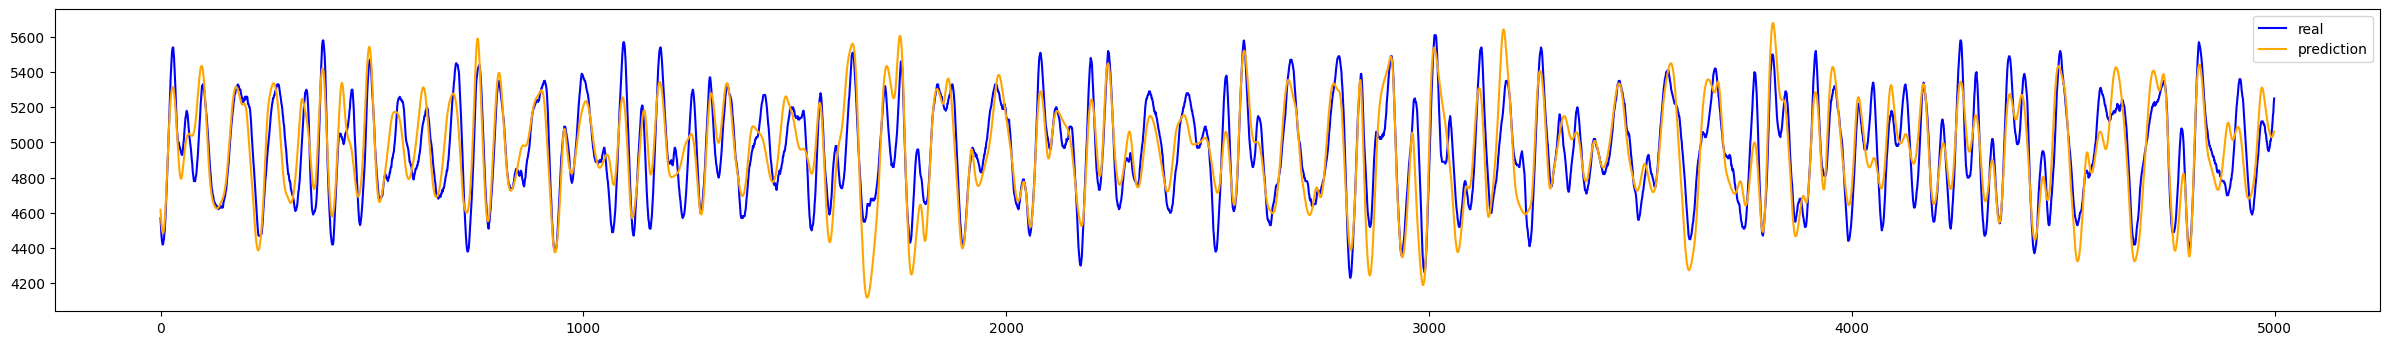

Acc: 0.9995027508753016


In [39]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force250_步长3.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长8）

In [40]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 6900, 7500, 12500)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_LSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 6600, 7500, 12500)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_LSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 6900, 7500, 12500)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_LSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 5000 samples
Epoch 1/30
 - 1s - loss: 0.0622 - val_loss: 0.0608
Epoch 2/30
 - 1s - loss: 0.0475 - val_loss: 0.0484
Epoch 3/30
 - 1s - loss: 0.0381 - val_loss: 0.0403
Epoch 4/30
 - 1s - loss: 0.0314 - val_loss: 0.0326
Epoch 5/30
 - 1s - loss: 0.0252 - val_loss: 0.0248
Epoch 6/30
 - 1s - loss: 0.0193 - val_loss: 0.0182
Epoch 7/30
 - 1s - loss: 0.0151 - val_loss: 0.0171
Epoch 8/30
 - 1s - loss: 0.0144 - val_loss: 0.0152
Epoch 9/30
 - 1s - loss: 0.0123 - val_loss: 0.0159
Epoch 10/30
 - 1s - loss: 0.0121 - val_loss: 0.0147
Epoch 11/30
 - 1s - loss: 0.0113 - val_loss: 0.0153
Epoch 12/30
 - 1s - loss: 0.0114 - val_loss: 0.0143
Epoch 13/30
 - 1s - loss: 0.0108 - val_loss: 0.0146
Epoch 14/30
 - 1s - loss: 0.0108 - val_loss: 0.0140
Epoch 15/30
 - 1s - loss: 0.0105 - val_loss: 0.0140
Epoch 16/30
 - 1s - loss: 0.0105 - val_loss: 0.0137
Epoch 17/30
 - 1s - loss: 0.0103 - val_loss: 0.0136
Epoch 18/30
 - 1s - loss: 0.0102 - val_loss: 0.0133
Epoch 19/30
 - 1s - loss: 

In [41]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

(600, 1)
(600, 1)
(600, 1)


In [42]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [43]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 6900, 7500, 12500)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [44]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.0406 - val_loss: 0.0326
Epoch 2/1000
 - 0s - loss: 0.0303 - val_loss: 0.0321
Epoch 3/1000
 - 0s - loss: 0.0257 - val_loss: 0.0202
Epoch 4/1000
 - 0s - loss: 0.0176 - val_loss: 0.0223
Epoch 5/1000
 - 0s - loss: 0.0166 - val_loss: 0.0211
Epoch 6/1000
 - 0s - loss: 0.0152 - val_loss: 0.0218
Epoch 7/1000
 - 0s - loss: 0.0170 - val_loss: 0.0240
Epoch 8/1000
 - 0s - loss: 0.0189 - val_loss: 0.0222
Epoch 9/1000
 - 0s - loss: 0.0173 - val_loss: 0.0204
Epoch 10/1000
 - 0s - loss: 0.0157 - val_loss: 0.0204
Epoch 11/1000
 - 0s - loss: 0.0151 - val_loss: 0.0204
Epoch 12/1000
 - 0s - loss: 0.0147 - val_loss: 0.0208
Epoch 13/1000
 - 0s - loss: 0.0152 - val_loss: 0.0217
Epoch 14/1000
 - 0s - loss: 0.0161 - val_loss: 0.0221
Epoch 15/1000
 - 0s - loss: 0.0164 - val_loss: 0.0217
Epoch 16/1000
 - 0s - loss: 0.0158 - val_loss: 0.0213
Epoch 17/1000
 - 0s - loss: 0.0153 - val_loss: 0.0213
Epoch 18/1000
 - 0s - loss: 0.0152 - val_los

 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 152/1000
 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 153/1000
 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 154/1000
 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 155/1000
 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 156/1000
 - 0s - loss: 0.0156 - val_loss: 0.0218
Epoch 157/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 158/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 159/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 160/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 161/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 162/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 163/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 164/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 165/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 166/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 167/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 168/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 169/1000
 - 0s - lo

Epoch 301/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 302/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 303/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 304/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 305/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 306/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 307/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 308/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 309/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 310/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 311/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 312/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 313/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 314/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 315/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 316/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 317/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 318/1000
 - 0s - loss: 0.0155 - val_loss: 0.0218
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 451/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 452/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 453/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 454/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 455/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 456/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 457/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 458/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 459/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 460/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 461/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 462/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 463/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 464/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 465/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 466/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 467/1000
 - 0s - loss: 0.0154 - val_loss: 0.0219
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 600/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 601/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 602/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 603/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 604/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 605/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 606/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 607/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 608/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 609/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 610/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 611/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 612/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 613/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 614/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 615/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 616/1000
 - 0s - loss: 0.0154 - val_loss: 0.0223
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0153 - val_loss: 0.0224
Epoch 749/1000
 - 0s - loss: 0.0153 - val_loss: 0.0224
Epoch 750/1000
 - 0s - loss: 0.0153 - val_loss: 0.0224
Epoch 751/1000
 - 0s - loss: 0.0153 - val_loss: 0.0224
Epoch 752/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 753/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 754/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 755/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 756/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 757/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 758/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 759/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 760/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 761/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 762/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 763/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 764/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 765/1000
 - 0s - loss: 0.0153 - val_loss: 0.0225
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0152 - val_loss: 0.0246
Epoch 898/1000
 - 0s - loss: 0.0152 - val_loss: 0.0247
Epoch 899/1000
 - 0s - loss: 0.0151 - val_loss: 0.0248
Epoch 900/1000
 - 0s - loss: 0.0151 - val_loss: 0.0248
Epoch 901/1000
 - 0s - loss: 0.0151 - val_loss: 0.0249
Epoch 902/1000
 - 0s - loss: 0.0151 - val_loss: 0.0250
Epoch 903/1000
 - 0s - loss: 0.0151 - val_loss: 0.0250
Epoch 904/1000
 - 0s - loss: 0.0151 - val_loss: 0.0251
Epoch 905/1000
 - 0s - loss: 0.0150 - val_loss: 0.0251
Epoch 906/1000
 - 0s - loss: 0.0150 - val_loss: 0.0252
Epoch 907/1000
 - 0s - loss: 0.0150 - val_loss: 0.0252
Epoch 908/1000
 - 0s - loss: 0.0150 - val_loss: 0.0252
Epoch 909/1000
 - 0s - loss: 0.0150 - val_loss: 0.0253
Epoch 910/1000
 - 0s - loss: 0.0150 - val_loss: 0.0253
Epoch 911/1000
 - 0s - loss: 0.0150 - val_loss: 0.0254
Epoch 912/1000
 - 0s - loss: 0.0149 - val_loss: 0.0254
Epoch 913/1000
 - 0s - loss: 0.0149 - val_loss: 0.0255
Epoch 914/1000
 - 0s - loss: 0.0149 - val_loss: 0.0256
Epoch 915/

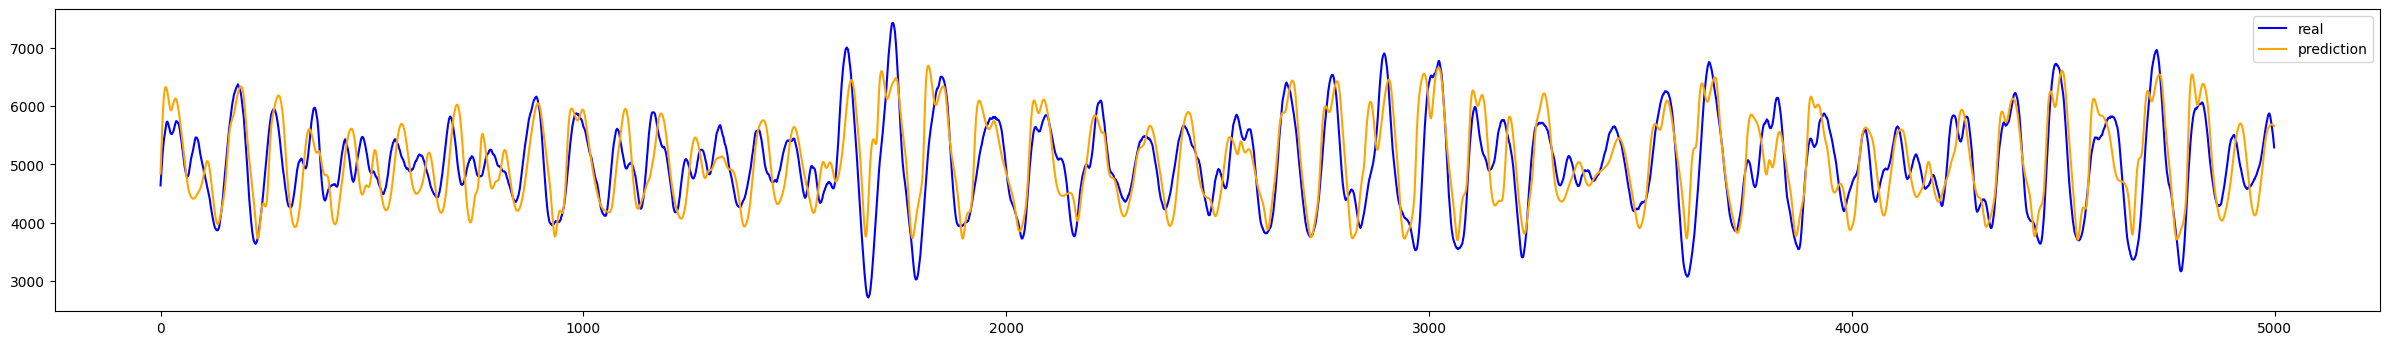

Acc: 0.9745819295087352


In [45]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force150_步长4.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [46]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[343:,:], 4, 57)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [47]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 6900, 7500, 12500)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [48]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 5000 samples
Epoch 1/1000
 - 0s - loss: 0.1195 - val_loss: 0.0561
Epoch 2/1000
 - 0s - loss: 0.0628 - val_loss: 0.0662
Epoch 3/1000
 - 0s - loss: 0.0594 - val_loss: 0.0461
Epoch 4/1000
 - 0s - loss: 0.0508 - val_loss: 0.0491
Epoch 5/1000
 - 0s - loss: 0.0547 - val_loss: 0.0473
Epoch 6/1000
 - 0s - loss: 0.0502 - val_loss: 0.0405
Epoch 7/1000
 - 0s - loss: 0.0423 - val_loss: 0.0390
Epoch 8/1000
 - 0s - loss: 0.0384 - val_loss: 0.0371
Epoch 9/1000
 - 0s - loss: 0.0347 - val_loss: 0.0338
Epoch 10/1000
 - 0s - loss: 0.0325 - val_loss: 0.0350
Epoch 11/1000
 - 0s - loss: 0.0334 - val_loss: 0.0347
Epoch 12/1000
 - 0s - loss: 0.0306 - val_loss: 0.0345
Epoch 13/1000
 - 0s - loss: 0.0273 - val_loss: 0.0363
Epoch 14/1000
 - 0s - loss: 0.0261 - val_loss: 0.0372
Epoch 15/1000
 - 0s - loss: 0.0269 - val_loss: 0.0387
Epoch 16/1000
 - 0s - loss: 0.0278 - val_loss: 0.0398
Epoch 17/1000
 - 0s - loss: 0.0269 - val_loss: 0.0412
Epoch 18/1000
 - 0s - loss: 0.0263 - val_los

 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 152/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 153/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 154/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 155/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 156/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 157/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 158/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 159/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 160/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 161/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 162/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 163/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 164/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 165/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 166/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 167/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 168/1000
 - 0s - loss: 0.0262 - val_loss: 0.0384
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 301/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 302/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 303/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 304/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 305/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 306/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 307/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 308/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 309/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 310/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 311/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 312/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 313/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 314/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 315/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 316/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 317/1000
 - 0s - loss: 0.0261 - val_loss: 0.0384
Epoch 318/1000
 - 0s - lo

Epoch 450/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 451/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 452/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 453/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 454/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 455/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 456/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 457/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 458/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 459/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 460/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 461/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 462/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 463/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 464/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 465/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 466/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 467/1000
 - 0s - loss: 0.0261 - val_loss: 0.0382
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0247 - val_loss: 0.0367
Epoch 600/1000
 - 0s - loss: 0.0247 - val_loss: 0.0367
Epoch 601/1000
 - 0s - loss: 0.0247 - val_loss: 0.0367
Epoch 602/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 603/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 604/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 605/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 606/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 607/1000
 - 0s - loss: 0.0246 - val_loss: 0.0367
Epoch 608/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 609/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 610/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 611/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 612/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 613/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 614/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 615/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 616/1000
 - 0s - loss: 0.0246 - val_loss: 0.0368
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0241 - val_loss: 0.0369
Epoch 749/1000
 - 0s - loss: 0.0241 - val_loss: 0.0369
Epoch 750/1000
 - 0s - loss: 0.0241 - val_loss: 0.0369
Epoch 751/1000
 - 0s - loss: 0.0241 - val_loss: 0.0369
Epoch 752/1000
 - 0s - loss: 0.0241 - val_loss: 0.0368
Epoch 753/1000
 - 0s - loss: 0.0241 - val_loss: 0.0368
Epoch 754/1000
 - 0s - loss: 0.0241 - val_loss: 0.0368
Epoch 755/1000
 - 0s - loss: 0.0240 - val_loss: 0.0368
Epoch 756/1000
 - 0s - loss: 0.0240 - val_loss: 0.0368
Epoch 757/1000
 - 0s - loss: 0.0240 - val_loss: 0.0367
Epoch 758/1000
 - 0s - loss: 0.0240 - val_loss: 0.0367
Epoch 759/1000
 - 0s - loss: 0.0239 - val_loss: 0.0366
Epoch 760/1000
 - 0s - loss: 0.0239 - val_loss: 0.0366
Epoch 761/1000
 - 0s - loss: 0.0239 - val_loss: 0.0365
Epoch 762/1000
 - 0s - loss: 0.0239 - val_loss: 0.0365
Epoch 763/1000
 - 0s - loss: 0.0238 - val_loss: 0.0364
Epoch 764/1000
 - 0s - loss: 0.0238 - val_loss: 0.0363
Epoch 765/1000
 - 0s - loss: 0.0237 - val_loss: 0.0363
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0251 - val_loss: 0.0441
Epoch 898/1000
 - 0s - loss: 0.0247 - val_loss: 0.0384
Epoch 899/1000
 - 0s - loss: 0.0252 - val_loss: 0.0397
Epoch 900/1000
 - 0s - loss: 0.0233 - val_loss: 0.0340
Epoch 901/1000
 - 0s - loss: 0.0221 - val_loss: 0.0340
Epoch 902/1000
 - 0s - loss: 0.0213 - val_loss: 0.0356
Epoch 903/1000
 - 0s - loss: 0.0213 - val_loss: 0.0343
Epoch 904/1000
 - 0s - loss: 0.0218 - val_loss: 0.0356
Epoch 905/1000
 - 0s - loss: 0.0212 - val_loss: 0.0342
Epoch 906/1000
 - 0s - loss: 0.0211 - val_loss: 0.0342
Epoch 907/1000
 - 0s - loss: 0.0210 - val_loss: 0.0351
Epoch 908/1000
 - 0s - loss: 0.0208 - val_loss: 0.0342
Epoch 909/1000
 - 0s - loss: 0.0210 - val_loss: 0.0348
Epoch 910/1000
 - 0s - loss: 0.0208 - val_loss: 0.0345
Epoch 911/1000
 - 0s - loss: 0.0207 - val_loss: 0.0344
Epoch 912/1000
 - 0s - loss: 0.0208 - val_loss: 0.0349
Epoch 913/1000
 - 0s - loss: 0.0206 - val_loss: 0.0345
Epoch 914/1000
 - 0s - loss: 0.0207 - val_loss: 0.0349
Epoch 915/

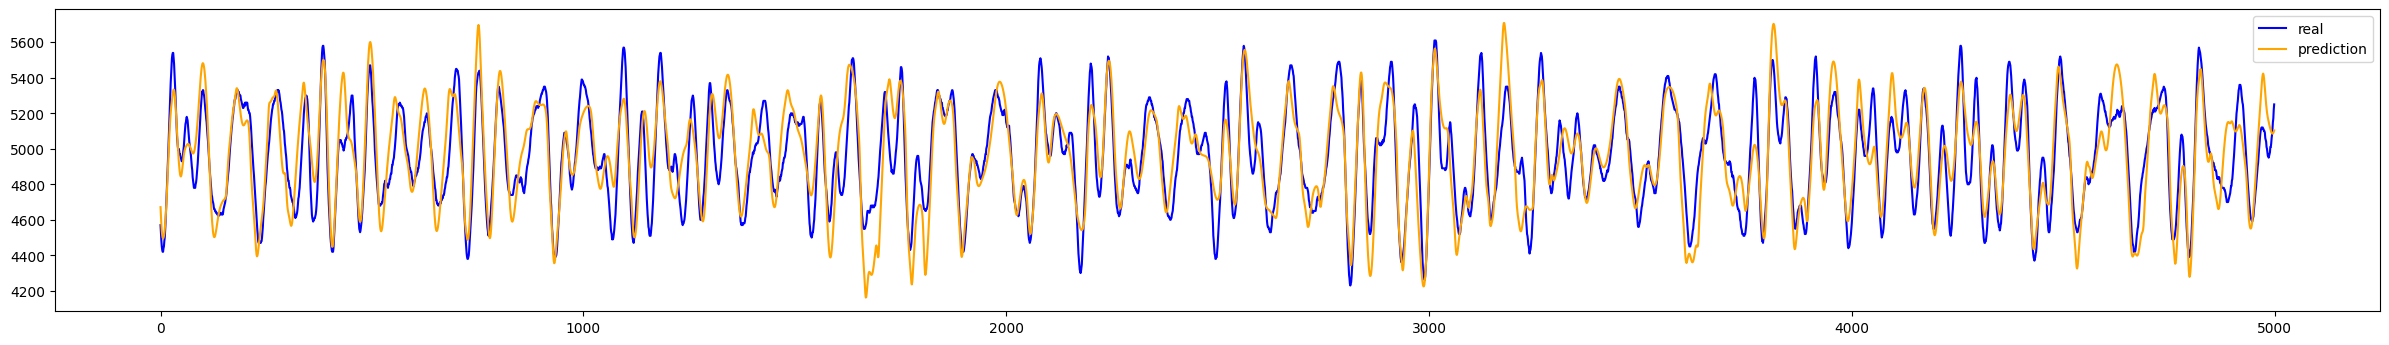

Acc: 0.9672145170380981


In [49]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force250_步长4.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')